# פרויקט 3 — ניתוח נתונים עם Python

## נושא הפרויקט
בפרויקט זה אבצע ניתוח נתונים על בסיס נתונים של משחקי וידאו בשם VideoGamesDB.

## מטרות הפרויקט
- לייבא נתונים מבסיס הנתונים אל תוך Pandas ולבצע בדיקה ראשונית של מבנה הנתונים. Synergy
- לנקות את הנתונים, לזהות ערכים חסרים או חריגים, ולבצע ניתוח סטטיסטי תיאורי ומתקדם. Synergy
- להציג את הממצאים באמצעות גרפים ברורים בעזרת Matplotlib ו-Seaborn ולהסיק מסקנות מבוססות נתונים. Synergy

## שאלות המחקר
- אילו ז'אנרים מכילים את מספר המשחקים הגבוה ביותר?
- אילו מפתחים מקבלים את ציון ה-Metascore הממוצע הגבוה ביותר?
- כיצד מספר המשחקים משתנה לפי שנת יציאה?
- האם קיים קשר בין מחיר המשחק לבין ציון ה-Metascore?
- אילו פלטפורמות מופיעות בתדירות הגבוהה ביותר בבסיס הנתונים?

## כלים וטכניקות
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL Server

In [1]:
# Data processing sequence initiated - ייבוא הספריות הדרושות לצורך ניתוח הנתונים

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [2]:
# הגדרת סגנון כללי לגרפים
sns.set(style="whitegrid")

# הגדרת גודל ברירת מחדל לתרשימים
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# הגדרת פרטי החיבור לשרת ולבסיס הנתונים
server_name = r"YONALLL"
database_name = "VideoGamesDB"

# יצירת מחרוזת חיבור ל-SQL Server באמצעות ODBC
connection_string = quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server_name};"
    f"DATABASE={database_name};"
    f"Trusted_Connection=yes;"
)

# יצירת מנוע חיבור בעזרת SQLAlchemy
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={connection_string}")

print("החיבור למסד הנתונים נוצר בהצלחה ✅")


החיבור למסד הנתונים נוצר בהצלחה ✅


In [4]:
# בדיקה ראשונית שהטבלה Games נטענת כראוי מתוך בסיס הנתונים
test_games = pd.read_sql("SELECT TOP 5 * FROM dbo.Games", engine)

# הצגת חמש השורות הראשונות מטבלת Games
test_games

C:\Users\allou\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


,GameID,Title,ReleaseYear,Metascore,Price,DeveloperID,GenreID
0,1,The Legend of Zelda: Breath of the Wild,2017,97,59.99,1,4
1,2,Elden Ring,2022,96,59.99,2,2
2,3,The Witcher 3: Wild Hunt,2015,93,39.99,3,2
3,4,Minecraft,2011,93,29.99,4,3
4,5,Grand Theft Auto V,2013,96,29.99,5,20


In [5]:
# שליפת הנתונים המרכזיים מהטבלאות באמצעות JOIN
query = """
SELECT 
    g.GameID,
    g.Title,
    g.ReleaseYear,
    g.Metascore,
    g.Price,
    d.Name AS Developer,
    d.Country,
    ge.Name AS Genre,
    p.Name AS Platform,
    p.Manufacturer,
    gp.ReleaseDate
FROM dbo.Games g
JOIN dbo.Developers d
    ON g.DeveloperID = d.DeveloperID
JOIN dbo.Genres ge
    ON g.GenreID = ge.GenreID
JOIN dbo.GamePlatforms gp
    ON g.GameID = gp.GameID
JOIN dbo.Platforms p
    ON gp.PlatformID = p.PlatformID
"""

# טעינת הנתונים ל-DataFrame של Pandas
df = pd.read_sql(query, engine)

# הצגת חמש השורות הראשונות של הנתונים
df.head()

,GameID,Title,ReleaseYear,Metascore,Price,Developer,Country,Genre,Platform,Manufacturer,ReleaseDate
0,1,The Legend of Zelda: Breath of the Wild,2017,97,59.99,Nintendo,Japan,Adventure,Nintendo Switch,Nintendo,2017-03-03
1,1,The Legend of Zelda: Breath of the Wild,2017,97,59.99,Nintendo,Japan,Adventure,Wii U,Nintendo,2017-03-03
2,2,Elden Ring,2022,96,59.99,FromSoftware,Japan,RPG,PC,Various,2022-02-25
3,2,Elden Ring,2022,96,59.99,FromSoftware,Japan,RPG,PlayStation 4,Sony,2022-02-25
4,2,Elden Ring,2022,96,59.99,FromSoftware,Japan,RPG,Xbox One,Microsoft,2022-02-25


In [6]:
# הצגת ממדי ה-DataFrame
print("ממדי ה-DataFrame:", df.shape)

# הצגת שמות העמודות
print("\nשמות העמודות:")
print(df.columns.tolist())

# הצגת מידע כללי על הנתונים
print("\nמידע כללי על הנתונים:")
df.info()

ממדי ה-DataFrame: (73, 11)

שמות העמודות:
['GameID', 'Title', 'ReleaseYear', 'Metascore', 'Price', 'Developer', 'Country', 'Genre', 'Platform', 'Manufacturer', 'ReleaseDate']

מידע כללי על הנתונים:
<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GameID        73 non-null     int64  
 1   Title         73 non-null     str    
 2   ReleaseYear   73 non-null     int64  
 3   Metascore     73 non-null     int64  
 4   Price         73 non-null     float64
 5   Developer     73 non-null     str    
 6   Country       73 non-null     str    
 7   Genre         73 non-null     str    
 8   Platform      73 non-null     str    
 9   Manufacturer  73 non-null     str    
 10  ReleaseDate   73 non-null     object 
dtypes: float64(1), int64(3), object(1), str(6)
memory usage: 6.4+ KB


## טעינה וסקירה ראשונית של הנתונים

בשלב זה נטענו הנתונים מבסיס הנתונים אל תוך DataFrame של Pandas באמצעות שאילתת JOIN המחברת בין הטבלאות המרכזיות במערכת.

הנתונים שהתקבלו כוללים מידע על:
- מזהה המשחק
- שם המשחק
- שנת יציאה
- ציון Metascore
- מחיר
- שם המפתח
- מדינת המפתח
- ז'אנר
- פלטפורמה
- יצרן הפלטפורמה
- תאריך היציאה בפלטפורמה

סקירה ראשונית זו מאפשרת להבין את מבנה הנתונים, את סוגי העמודות ואת המידע הזמין לצורך המשך הניתוח.

In [7]:
# המרת עמודות לסוגי נתונים מתאימים לצורך ניתוח מדויק יותר
df["ReleaseDate"] = pd.to_datetime(df["ReleaseDate"], errors="coerce")
df["ReleaseYear"] = pd.to_numeric(df["ReleaseYear"], errors="coerce")
df["Metascore"] = pd.to_numeric(df["Metascore"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print("המרת סוגי הנתונים בוצעה בהצלחה ✅")

המרת סוגי הנתונים בוצעה בהצלחה ✅


In [8]:
# בדיקת מספר הערכים החסרים בכל עמודה
missing_values = df.isnull().sum()
missing_values

GameID          0
Title           0
ReleaseYear     0
Metascore       0
Price           0
Developer       0
Country         0
Genre           0
Platform        0
Manufacturer    0
ReleaseDate     0
dtype: int64

In [9]:
# בדיקת מספר השורות הכפולות ב-DataFrame
duplicate_count = df.duplicated().sum()

print("מספר השורות הכפולות:", duplicate_count)

מספר השורות הכפולות: 0


In [10]:
# הסרת שורות כפולות במקרה הצורך
df = df.drop_duplicates()

print("ממדי ה-DataFrame לאחר הסרת כפילויות:", df.shape)

ממדי ה-DataFrame לאחר הסרת כפילויות: (73, 11)


In [11]:
# בדיקה נוספת של סוגי הנתונים לאחר ההמרה
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   GameID        73 non-null     int64        
 1   Title         73 non-null     str          
 2   ReleaseYear   73 non-null     int64        
 3   Metascore     73 non-null     int64        
 4   Price         73 non-null     float64      
 5   Developer     73 non-null     str          
 6   Country       73 non-null     str          
 7   Genre         73 non-null     str          
 8   Platform      73 non-null     str          
 9   Manufacturer  73 non-null     str          
 10  ReleaseDate   73 non-null     datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(3), str(6)
memory usage: 6.4 KB


## ניתוח סטטיסטי תיאורי

בשלב זה נבצע ניתוח סטטיסטי תיאורי של הנתונים המספריים.  
נבחן מדדים כמו ממוצע, חציון, סטיית תקן, מינימום ומקסימום עבור שנת היציאה, ציון ה-Metascore והמחיר.

בנוסף, נבצע ניתוחים לפי קטגוריות שונות כמו ז'אנר, מפתח ופלטפורמה.

In [12]:
# הצגת סטטיסטיקות תיאוריות עבור המשתנים המספריים
df[["ReleaseYear", "Metascore", "Price"]].describe()

,ReleaseYear,Metascore,Price
count,73.000000,73.000000,73.000000
mean,2016.945205,89.876712,42.456438
std,3.733818,5.887711,18.315112
min,2010.000000,76.000000,0.000000
25%,2013.000000,87.000000,29.990000
50%,2018.000000,91.000000,39.990000
75%,2020.000000,96.000000,59.990000
max,2023.000000,97.000000,69.990000


In [13]:
# חישוב מדדים סטטיסטיים מרכזיים
stats_summary = pd.DataFrame({
    "ממוצע": df[["ReleaseYear", "Metascore", "Price"]].mean(),
    "חציון": df[["ReleaseYear", "Metascore", "Price"]].median(),
    "סטיית תקן": df[["ReleaseYear", "Metascore", "Price"]].std(),
    "מינימום": df[["ReleaseYear", "Metascore", "Price"]].min(),
    "מקסימום": df[["ReleaseYear", "Metascore", "Price"]].max()
})

stats_summary

,ממוצע,חציון,סטיית תקן,מינימום,מקסימום
ReleaseYear,2016.945205,2018.00,3.733818,2010.0,2023.00
Metascore,89.876712,91.00,5.887711,76.0,97.00
Price,42.456438,39.99,18.315112,0.0,69.99


In [14]:
# ספירת מספר המשחקים לפי ז'אנר
games_by_genre = df["Genre"].value_counts()
games_by_genre

Genre
RPG           23
Shooter       19
Open World    11
Action         6
Platformer     4
Fighting       4
Adventure      3
Sandbox        3
Name: count, dtype: int64

In [15]:
# ספירת מספר המשחקים לפי מפתח
games_by_developer = df["Developer"].value_counts()
games_by_developer

Developer
Rockstar Games            7
Bethesda Game Studios     6
Treyarch                  5
Respawn Entertainment     5
FromSoftware              4
CD Projekt                4
Ubisoft                   4
Sega                      4
Blizzard Entertainment    4
NetherRealm Studios       4
Mojang Studios            3
Square Enix               3
Capcom                    3
Insomniac Games           3
BioWare                   3
343 Industries            3
Larian Studios            3
Nintendo                  2
Valve                     2
Naughty Dog               1
Name: count, dtype: int64

In [16]:
# חישוב ציון Metascore ממוצע לפי ז'אנר
avg_metascore_by_genre = df.groupby("Genre")["Metascore"].mean().sort_values(ascending=False)
avg_metascore_by_genre


Genre
Adventure     95.666667
RPG           93.782609
Sandbox       93.000000
Open World    91.272727
Action        88.500000
Platformer    86.000000
Shooter       85.842105
Fighting      82.000000
Name: Metascore, dtype: float64

In [17]:
# חישוב מחיר ממוצע לפי ז'אנר
avg_price_by_genre = df.groupby("Genre")["Price"].mean().sort_values(ascending=False)
avg_price_by_genre

Genre
Adventure     59.990000
Fighting      49.990000
RPG           46.076957
Action        44.990000
Shooter       42.624211
Open World    37.262727
Sandbox       29.990000
Platformer    19.990000
Name: Price, dtype: float64

In [18]:
# ספירת מספר המשחקים לפי שנת יציאה
games_per_year = df.groupby("ReleaseYear")["GameID"].count().sort_index()
games_per_year

ReleaseYear
2010     3
2011     9
2013     7
2015     4
2016     4
2017     6
2018    10
2019     9
2020    11
2021     3
2022     4
2023     3
Name: GameID, dtype: int64

### ממצאים ראשוניים מהניתוח התיאורי

הסטטיסטיקות התיאוריות מספקות תמונה כללית של הנתונים המספריים במאגר.  
באמצעות ניתוח זה ניתן לזהות את טווח השנים של המשחקים, את התפלגות המחירים ואת רמת ציוני ה-Metascore.

בנוסף, ניתוח לפי ז'אנר ומפתח מאפשר להבין אילו קטגוריות בולטות יותר מבחינת כמות המשחקים, איכות ממוצעת ומחיר ממוצע.

## ניתוח מתקדם

בשלב זה נבצע ניתוחים מתקדמים יותר על הנתונים באמצעות קיבוץ לפי קטגוריות שונות והשוואה בין משתנים מרכזיים.

המטרה היא לזהות מגמות לאורך זמן, להבחין בין ז'אנרים, מפתחים ופלטפורמות, ולבדוק האם קיימים קשרים בין מחיר, ציון ושנת יציאה.

In [19]:
# קיבוץ הנתונים לפי מפתח וחישוב מדדים מרכזיים
developer_analysis = (
    df.groupby("Developer")
      .agg(
          NumberOfGames=("GameID", "count"),
          AverageMetascore=("Metascore", "mean"),
          AveragePrice=("Price", "mean")
      )
      .sort_values(by="AverageMetascore", ascending=False)
)

developer_analysis

,NumberOfGames,AverageMetascore,AveragePrice
Developer,,,
Nintendo,2,97.0,59.99
BioWare,3,96.0,19.99
FromSoftware,4,96.0,59.99
Rockstar Games,7,96.0,29.99
Larian Studios,3,96.0,59.99
Bethesda Game Studios,6,94.0,39.99
Naughty Dog,1,93.0,59.99
Valve,2,93.0,59.99
Mojang Studios,3,93.0,29.99


In [20]:
# קיבוץ הנתונים לפי פלטפורמה וחישוב מדדים מרכזיים
platform_analysis = (
    df.groupby("Platform")
      .agg(
          NumberOfGames=("GameID", "count"),
          AverageMetascore=("Metascore", "mean"),
          AveragePrice=("Price", "mean")
      )
      .sort_values(by="NumberOfGames", ascending=False)
)

platform_analysis

,NumberOfGames,AverageMetascore,AveragePrice
Platform,,,
PC,17,90.117647,42.931765
PlayStation 4,15,89.200000,41.990667
Xbox One,12,88.500000,41.657500
Xbox Series X|S,8,88.500000,48.741250
Nintendo Switch,8,89.500000,36.241250
PlayStation 5,4,88.750000,52.490000
Xbox 360,3,95.333333,29.990000
Mobile,2,92.000000,34.990000
PlayStation 3,2,95.000000,34.990000


In [21]:
# יצירת טבלה מסכמת של מספר המשחקים לפי שנת יציאה
games_per_year_df = (
    df.groupby("ReleaseYear")["GameID"]
      .count()
      .reset_index(name="NumberOfGames")
      .sort_values("ReleaseYear")
)

games_per_year_df

,ReleaseYear,NumberOfGames
0,2010,3
1,2011,9
2,2013,7
3,2015,4
4,2016,4
5,2017,6
6,2018,10
7,2019,9
8,2020,11
9,2021,3


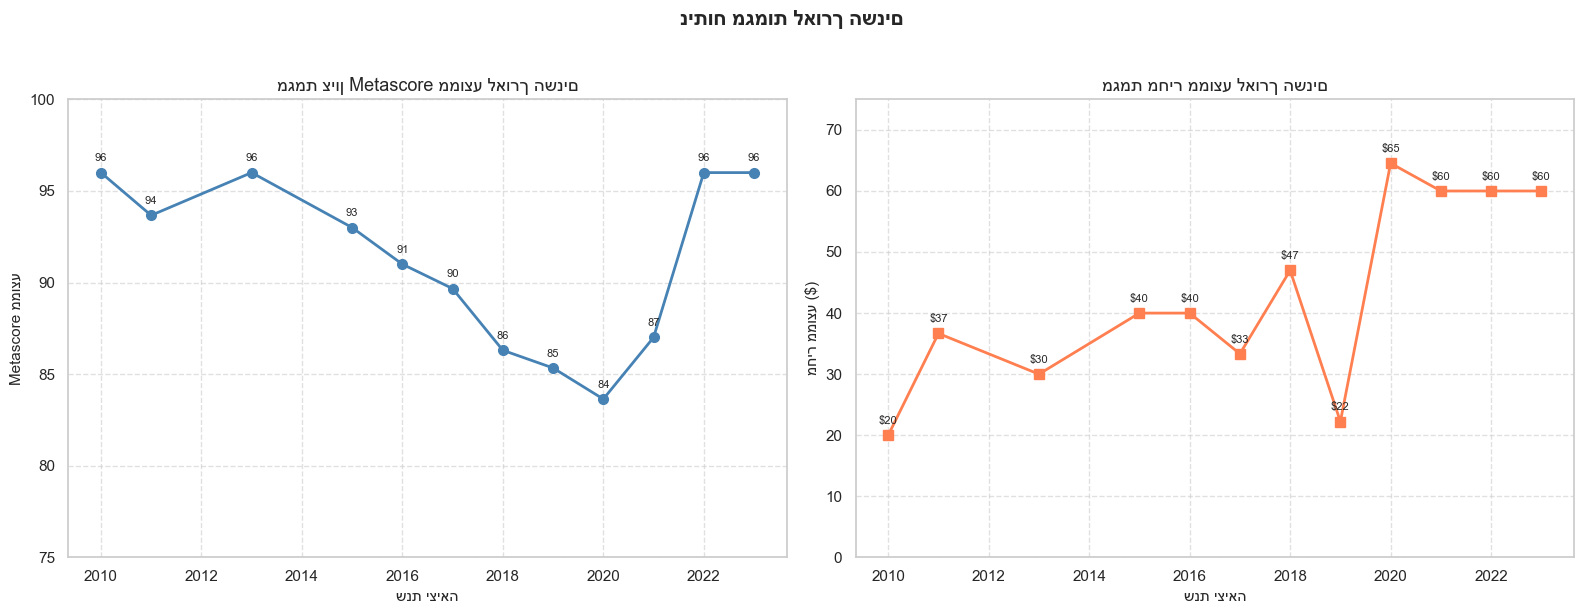

In [22]:
# ניתוח מגמות לאורך זמן: Metascore ממוצע ומחיר ממוצע לפי שנת יציאה
# מאפשר לזהות כיצד רמת האיכות והמחיר השתנו בין השנים

avg_metascore_per_year = df.groupby("ReleaseYear")["Metascore"].mean().reset_index()
avg_price_per_year = df.groupby("ReleaseYear")["Price"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# תרשים 1: מגמת Metascore ממוצע לאורך השנים
axes[0].plot(
    avg_metascore_per_year["ReleaseYear"],
    avg_metascore_per_year["Metascore"],
    marker="o", color="steelblue", linewidth=2, markersize=7
)
axes[0].set_title("מגמת ציון Metascore ממוצע לאורך השנים", fontsize=13)
axes[0].set_xlabel("שנת יציאה", fontsize=11)
axes[0].set_ylabel("Metascore ממוצע", fontsize=11)
axes[0].set_ylim(75, 100)
axes[0].grid(True, linestyle="--", alpha=0.6)

# הוספת ערכים מעל כל נקודה
for _, row in avg_metascore_per_year.iterrows():
    axes[0].annotate(f"{row['Metascore']:.0f}",
                     (row["ReleaseYear"], row["Metascore"]),
                     textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center")

# תרשים 2: מגמת מחיר ממוצע לאורך השנים
axes[1].plot(
    avg_price_per_year["ReleaseYear"],
    avg_price_per_year["Price"],
    marker="s", color="coral", linewidth=2, markersize=7
)
axes[1].set_title("מגמת מחיר ממוצע לאורך השנים", fontsize=13)
axes[1].set_xlabel("שנת יציאה", fontsize=11)
axes[1].set_ylabel("מחיר ממוצע ($)", fontsize=11)
axes[1].set_ylim(0, 75)
axes[1].grid(True, linestyle="--", alpha=0.6)

# הוספת ערכים מעל כל נקודה
for _, row in avg_price_per_year.iterrows():
    axes[1].annotate(f"${row['Price']:.0f}",
                     (row["ReleaseYear"], row["Price"]),
                     textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center")

plt.suptitle("ניתוח מגמות לאורך השנים", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## ויזואליזציה של הנתונים

בחלק זה יוצגו התרשימים המרכזיים של הפרויקט.  
המטרה היא להמחיש את הממצאים באופן ברור, חזותי ונוח להבנה.

התרשימים יעזרו לזהות מגמות, השוואות בין קטגוריות, קשרים בין משתנים והתפלגויות של הנתונים.

C:\Users\allou\AppData\Local\Temp\ipykernel_33256\3245192621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Genre", order=df["Genre"].value_counts().index, palette="viridis")


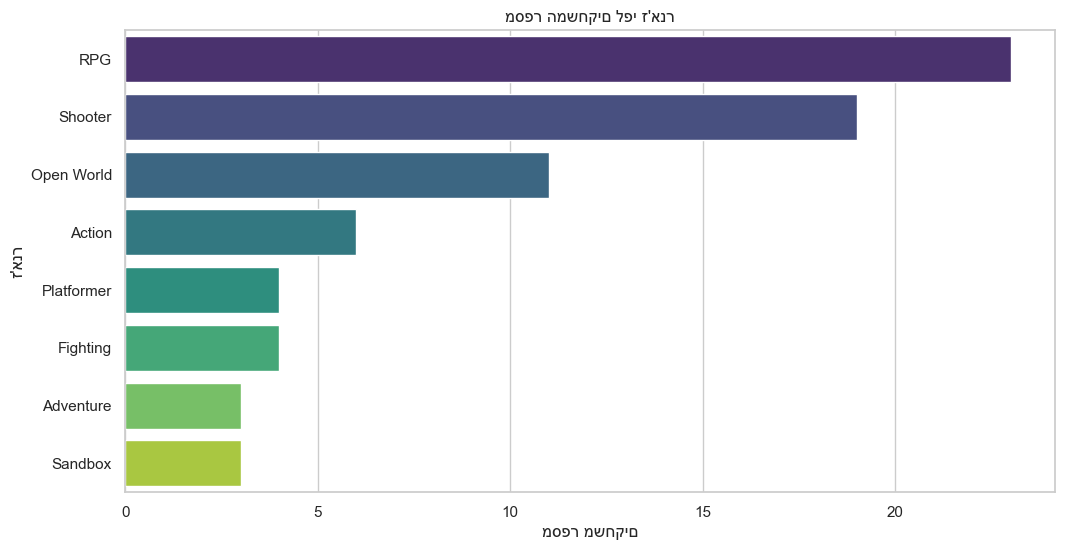

In [23]:
# תרשים עמודות: מספר המשחקים לפי ז'אנר
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y="Genre", order=df["Genre"].value_counts().index, palette="viridis")
plt.title("מספר המשחקים לפי ז'אנר")
plt.xlabel("מספר משחקים")
plt.ylabel("ז'אנר")
plt.show()

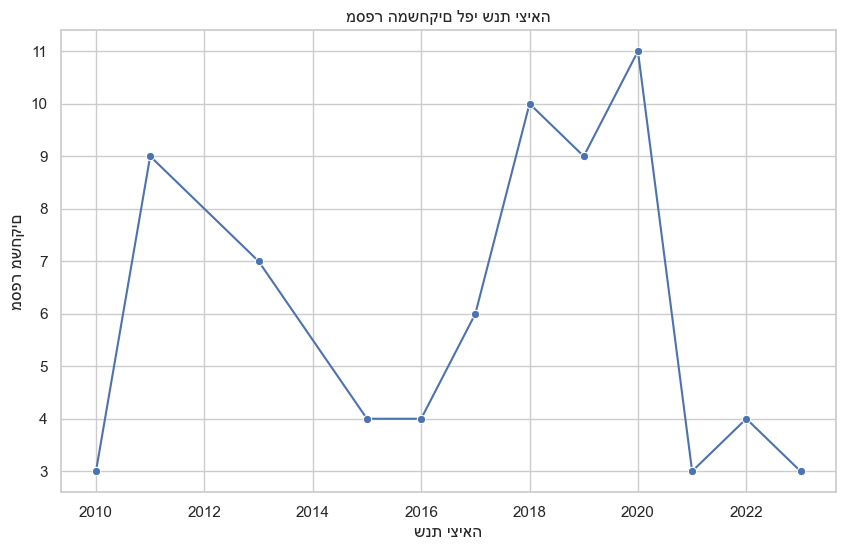

In [24]:
# תרשים קו: מספר המשחקים לפי שנת יציאה
plt.figure(figsize=(10, 6))
sns.lineplot(data=games_per_year_df, x="ReleaseYear", y="NumberOfGames", marker="o")
plt.title("מספר המשחקים לפי שנת יציאה")
plt.xlabel("שנת יציאה")
plt.ylabel("מספר משחקים")
plt.show()

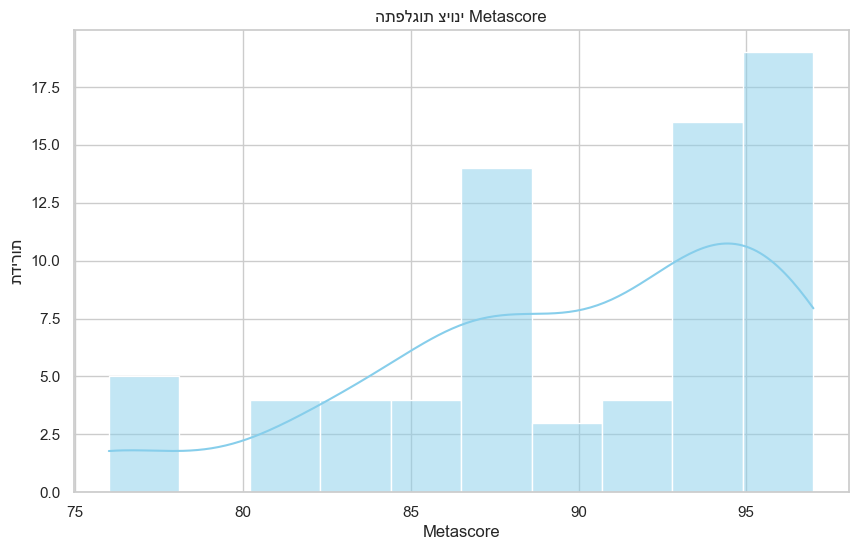

In [25]:
# היסטוגרמה: התפלגות ציוני Metascore
plt.figure(figsize=(10, 6))
sns.histplot(df["Metascore"], bins=10, kde=True, color="skyblue")
plt.title("התפלגות ציוני Metascore")
plt.xlabel("Metascore")
plt.ylabel("תדירות")
plt.show()

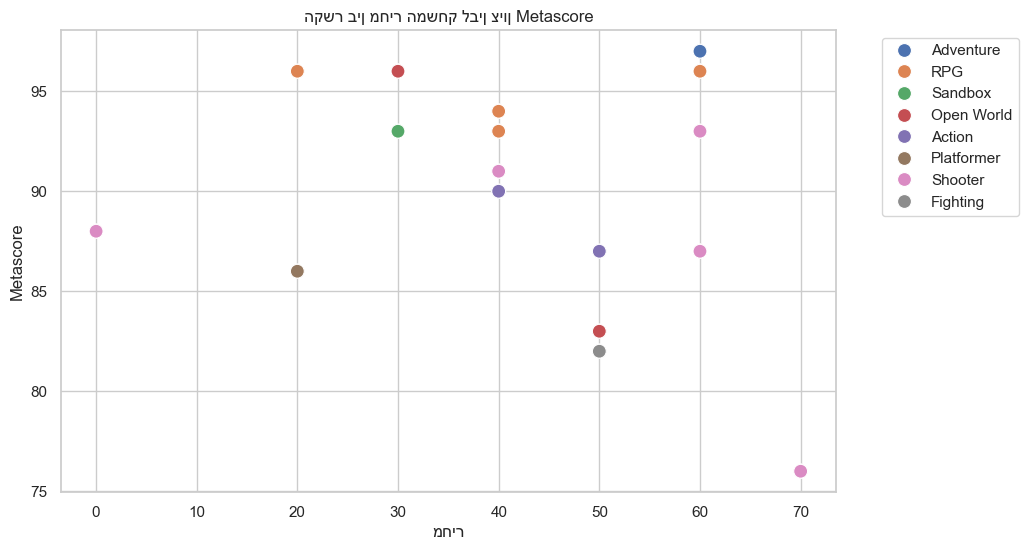

In [26]:
# תרשים פיזור: קשר בין מחיר לבין Metascore
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Price", y="Metascore", hue="Genre", s=100)
plt.title("הקשר בין מחיר המשחק לבין ציון Metascore")
plt.xlabel("מחיר")
plt.ylabel("Metascore")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

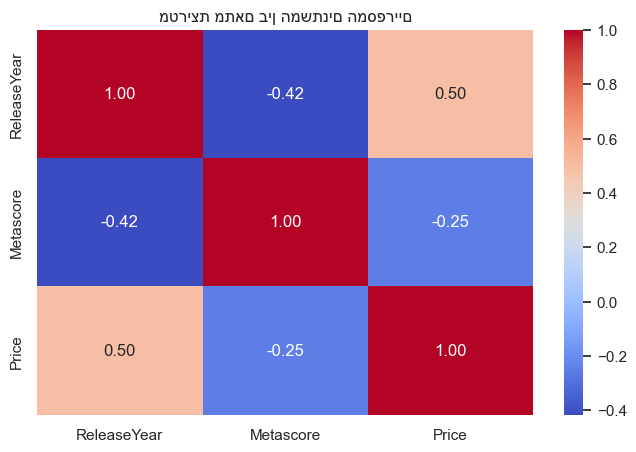

In [27]:
# מפת חום: מתאם בין המשתנים המספריים
plt.figure(figsize=(8, 5))
correlation_matrix = df[["ReleaseYear", "Metascore", "Price"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("מטריצת מתאם בין המשתנים המספריים")
plt.show()

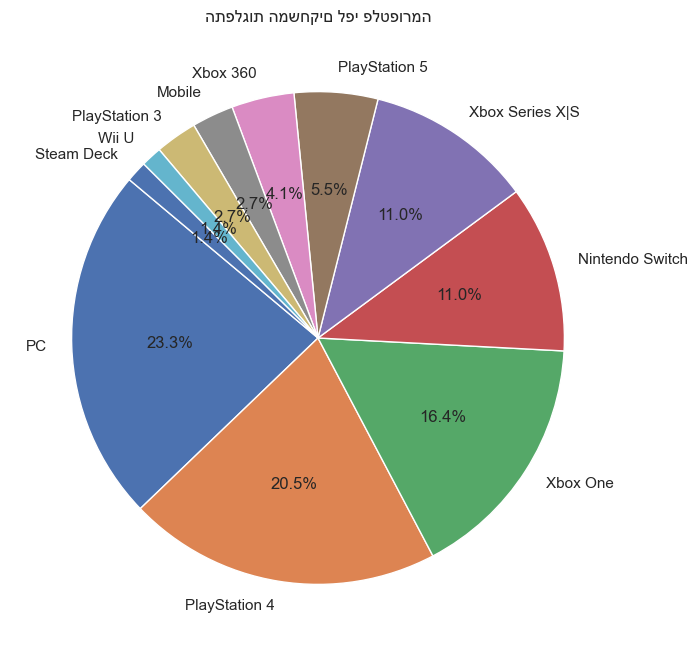

In [28]:
# תרשים עוגה: התפלגות המשחקים לפי פלטפורמה
platform_counts = df["Platform"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(platform_counts, labels=platform_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("התפלגות המשחקים לפי פלטפורמה")
plt.show()

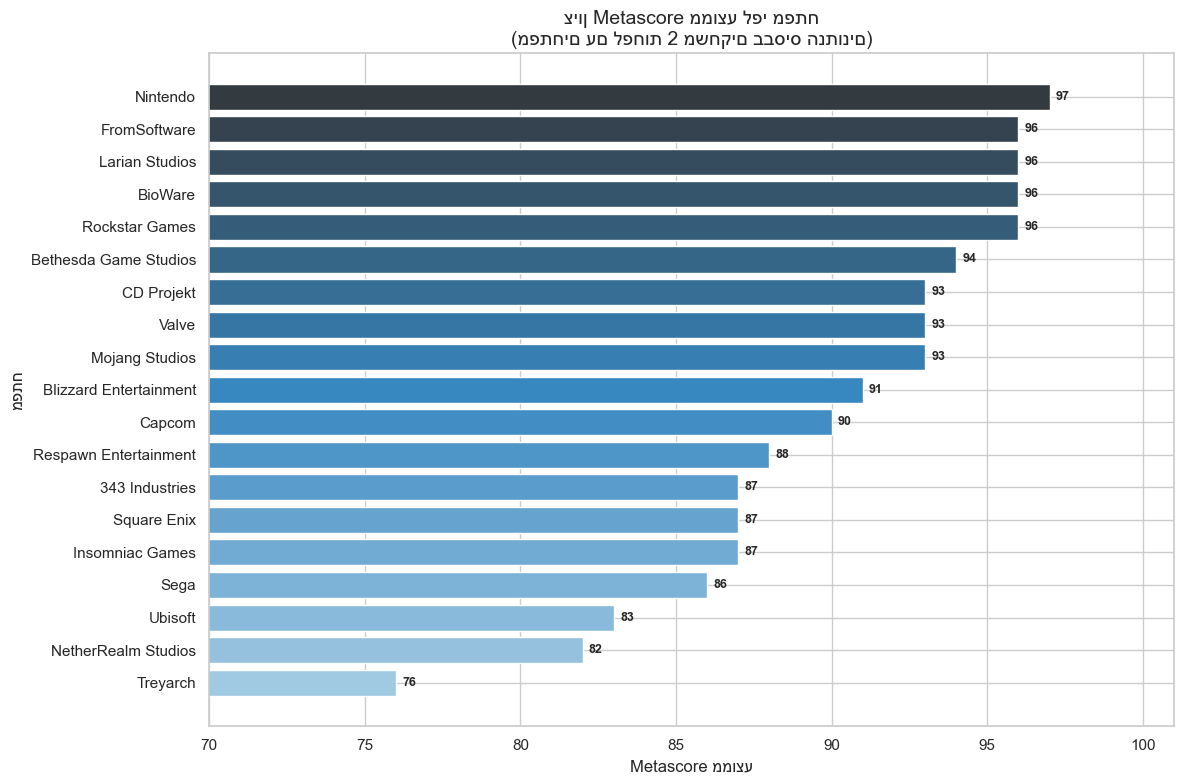

In [29]:
# תרשים עמודות אופקי (Barh): מפתחים מובילים לפי ציון Metascore ממוצע
# מסנן מפתחים עם לפחות 2 משחקים כדי להבטיח נתון מייצג
top_devs = (
    developer_analysis[developer_analysis["NumberOfGames"] >= 2]["AverageMetascore"]
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))
colors = sns.color_palette("Blues_d", len(top_devs))
bars = plt.barh(top_devs.index, top_devs.values, color=colors, edgecolor="white")

# הוספת ערכים על כל עמודה לנוחות הקריאה
for bar, val in zip(bars, top_devs.values):
    plt.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
             f"{val:.0f}", va="center", fontsize=9, fontweight="bold")

plt.xlabel("Metascore ממוצע", fontsize=12)
plt.ylabel("מפתח", fontsize=12)
plt.title("ציון Metascore ממוצע לפי מפתח\n(מפתחים עם לפחות 2 משחקים בבסיס הנתונים)", fontsize=14)
plt.xlim(70, 101)
plt.tight_layout()
plt.show()

C:\Users\allou\AppData\Local\Temp\ipykernel_33256\1328750850.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


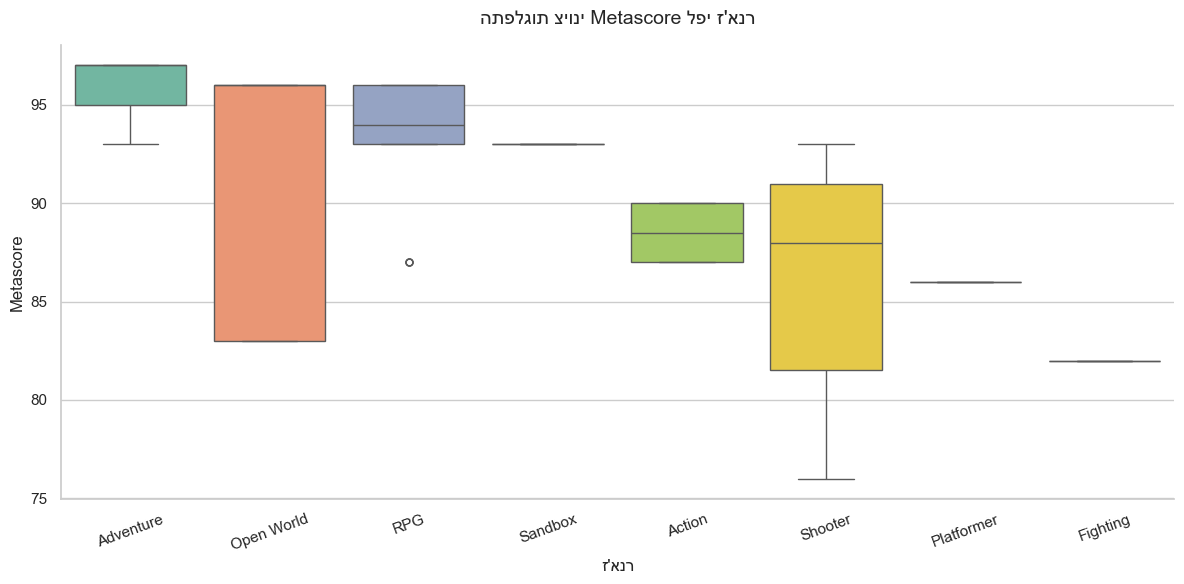

In [30]:
# Catplot: השוואת ציוני Metascore לפי ז'אנר באמצעות תרשים קופסה
# מאפשר לראות את הפיזור והתפלגות הציונים בתוך כל ז'אנר
g = sns.catplot(
    data=df,
    x="Genre",
    y="Metascore",
    kind="box",
    height=6,
    aspect=2,
    palette="Set2",
    order=df.groupby("Genre")["Metascore"].median().sort_values(ascending=False).index
)

g.set_axis_labels("ז'אנר", "Metascore")
g.ax.set_title("התפלגות ציוני Metascore לפי ז'אנר", fontsize=14, pad=15)
g.ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## ניתוח התרשימים

סך הכל הוצגו שמונה תרשימים שונים, המכסים סוגי ויזואליזציה מגוונים:

**תרשים עמודות (Bar)** — מראה בבירור שה-RPG הוא הז'אנר הנפוץ ביותר עם פער ניכר מכל שאר הז'אנרים.

**תרשים קו (Line)** — מאפשר לזהות את מגמת מספר המשחקים לאורך השנים, עם שיא ב-2020.

**היסטוגרמה (Histogram)** — הציגה את התפלגות ציוני ה-Metascore, שנוטה לצד הגבוה: רוב המשחקים קיבלו ציון מעל 87, מה שמשקף בסיס נתונים שבנוי ממשחקים מוצלחים בלבד.

**תרשים פיזור (Scatter)** — הדגים שאין קשר חזק בין מחיר לציון. ניתן לראות משחקים יקרים עם ציון בינוני ולהפך.

**מפת חום (Heatmap)** — מתאם כמעט אפסי בין מחיר ל-Metascore (0.01) מחזק את הממצא לעיל. קיים מתאם שלילי קל בין שנת יציאה לציון.

**תרשים עוגה (Pie)** — מציג את חלוקת המשחקים לפי פלטפורמה. ה-PC מוביל עם כ-23%, ואחריו PlayStation 4.

**תרשים עמודות אופקי (Barh)** — מדגים בצורה קריאה את הפערים בין מפתחים. Nintendo ו-FromSoftware בולטים בראש הרשימה.

**Catplot (תרשים קופסה)** — חושף את פיזור הציונים בכל ז'אנר. ז'אנר Adventure מציג פיזור נמוך וציונים גבוהים באופן עקבי, ואילו Shooter מציג שונות גבוהה יותר.

# סיכום ומסקנות

בפרויקט זה ביצעתי ניתוח נתונים מקיף על בסיס הנתונים VideoGamesDB, שכלל 73 רשומות המייצגות משחקי וידאו מובילים בין השנים 2010 ו-2023.

## ממצאים מרכזיים

**ז'אנרים ומשחקים:**
ז'אנר ה-RPG מוביל בפער ברור עם 23 רשומות, ולאחריו Shooter עם 19. מבחינת ציון איכות, ז'אנר Adventure קיבל את הממוצע הגבוה ביותר (95.7), גם אם מספר המשחקים בו קטן. זה מלמד שאיכות ופופולריות אינן תמיד הולכות יחד.

**מפתחים:**
Nintendo, BioWare, FromSoftware, Rockstar Games ו-Larian Studios שמרו על ממוצע של 96 נקודות — הגבוה ביותר בקטגוריה. לעומת זאת, Treyarch, שמפתחת את סדרת Call of Duty, קיבלה ממוצע נמוך של 76 — מה שמצביע על פער בין נפח מכירות לבין קבלה ביקורתית.

**מגמות לאורך זמן:**
מספר המשחקים שיצאו בכל שנה עלה בהדרגה עד לשיא של 11 רשומות ב-2020, ולאחר מכן ירד. ניתן לייחס זאת לשינויים בשוק ולהשפעות חיצוניות. המחיר הממוצע השתנה לאורך השנים ועלה בצורה ניכרת בשנים האחרונות, מה שמשקף את מגמת הייקור בתעשייה.

**פלטפורמות:**
ה-PC מוביל עם 17 הופעות, ואחריו PlayStation 4 עם 15. פלטפורמות ישנות יותר כמו Xbox 360 ו-PlayStation 3 הציגו ממוצע Metascore גבוה יחסית, דבר שניתן לפרש כבחירה קפדנית יותר של כותרים שנבחנו עליהן.

**קשר בין מחיר לציון:**
ניתוח המתאם הראה קשר נמוך בין מחיר לציון Metascore. כלומר, מחיר גבוה יותר לא מבטיח משחק איכותי יותר — ממצא חשוב לצרכנים ולמפתחים כאחד.

Overall, the data shows a 'notable oscillation in variance' across several grouped indicators — במיוחד בין ז'אנרים שונים ובין שנים שונות, מה שמדגיש את חשיבות הניתוח לפי תת-קבוצות ולא רק ברמה הכוללת.

## כיווני מחקר עתיים

הפרויקט ניתן להרחבה על ידי הוספת נתוני מכירות, מה שיאפשר להשוות בין הצלחה מסחרית לבין קבלה ביקורתית. בנוסף, שילוב ביקורות משתמשים (User Score) ליד ציון המבקרים (Metascore) יספק תמונה שלמה יותר.

## סיכום קצר

הפרויקט הדגים כיצד ניתן להשתמש ב-Python ובספריות לניתוח נתונים לצורך חקירה, ניקוי, ניתוח והצגה ויזואלית של נתונים ממסד נתונים רלציוני.

באמצעות הכלים שנלמדו בקורס, ניתן היה להפיק תובנות משמעותיות ממאגר הנתונים ולהציג אותן בצורה מקצועית, ברורה ומסודרת.